<a href="https://colab.research.google.com/github/BonneyBoja/BonneyBoja.github.io/blob/main/Kmeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

In [4]:
data = pd.read_csv('Mall_Customers.csv')

In [5]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
X=data[['Annual Income (k$)','Spending Score (1-100)']].values

In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [8]:
wss=[]
sil_score=[]
k_range=range(2,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X_scaled,kmeans.labels_))

Able Graph

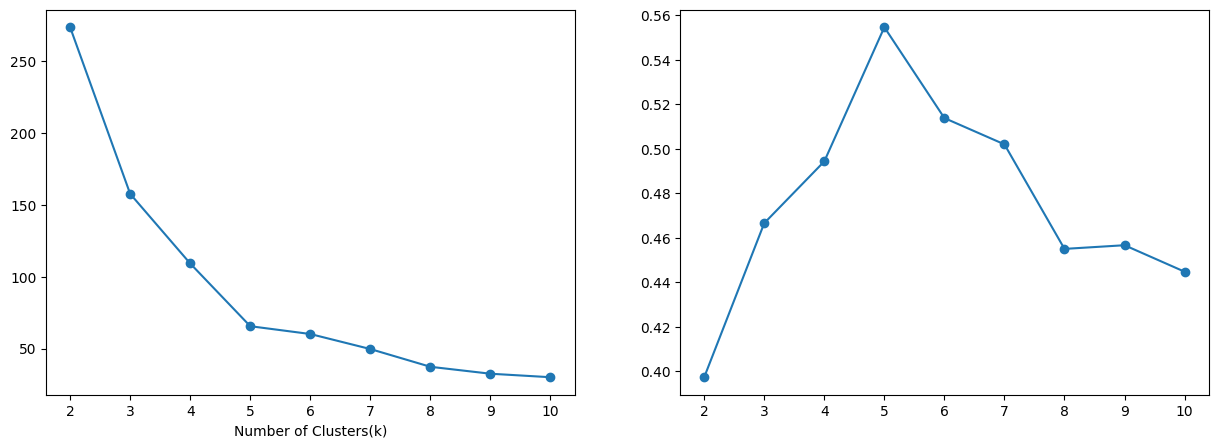

In [9]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
k_range = range(2,11) # Re-defining k_range to resolve NameError. This must match the range used to generate wss and sil_score.
ax[0].plot(k_range,wss,'-o')
ax[0].set_xlabel('Number of Clusters(k)')
ax
ax[1].plot(k_range,sil_score,'-o')

In [10]:
optimal_k=k_range[sil_score.index(max(sil_score))]
print(f"Optimal number of clusters: {optimal_k}")

Optimal number of clusters: 5


In [11]:
kmeans=KMeans(n_clusters=optimal_k,random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

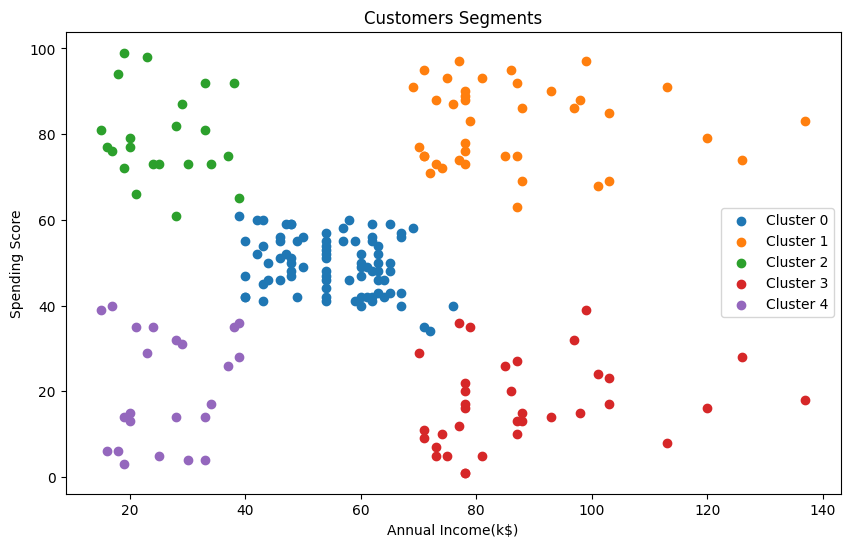

In [13]:
data['Cluster'] = kmeans.labels_
plt.figure(figsize=(10,6))
for i in range(optimal_k):
    plt.scatter(X[data['Cluster']==i][:,0],X[data['Cluster']==i][:,1],label=f'Cluster {i}')
    plt.xlabel('Annual Income(k$)')
    plt.ylabel('Spending Score')
    plt.title('Customers Segments')
    plt.legend()
plt.show()

In [15]:
print(data.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
